# Pandas

Empecemos con las buenas prácticas.<br>
Lo primero que nos conviene es tener un modelo de datos objetivo, hacia el que se organizarán y tratarán los dataframes de múltiples fuentes.<br>
A veces nos tocará investigar la lógica de negocio para que el modelo de datos sea coherente, incluso en detalles como la notación de la presión arterial o que el personal de salud prefiere un único campo para fecha y hora de ingreso del paciente.

In [3]:
import pandas as pd

class Paciente:
  COL_EDAD = "Edad"
  COL_ESTATURA = "Estatura (m)"
  COL_INGRESO = "Ingreso"
  COL_PACIENTE = "Paciente"
  COL_PESO = "Peso (kg)"
  COL_SEXO = "Sexo"
  COL_TEMPERATURA = "T °C"
  COL_TENSION_ARTERIAL = "T/A (mmHg)"

Veamos cómo importar una hoja de cálculo de Excel.

In [8]:
df_excel = pd.read_excel("https://drive.google.com/uc?id=1QntBQjz-oFEE2kTK1zXw4SqLDTck2ONi", sheet_name="Hoja1")

df_excel = df_excel.rename(columns={"altura": Paciente.COL_ESTATURA,
                                    "peso":Paciente.COL_PESO,
                                    "temperatura": Paciente.COL_TEMPERATURA})

df_excel[Paciente.COL_TENSION_ARTERIAL] = df_excel["presion sistólica"].astype(str) + "/" + df_excel["presión diastólica"].astype(str)
df_excel = df_excel.drop(columns=["presion sistólica", "presión diastólica"])

df_excel[Paciente.COL_INGRESO] = df_excel["fecha"].astype(str) + " " + df_excel["hora"].astype(str)
df_excel = df_excel.drop(columns=["fecha", "hora"])

df_excel.columns = df_excel.columns.map(lambda c: c if c[0].isupper() else c.capitalize())

df_excel[Paciente.COL_PACIENTE] = df_excel[Paciente.COL_PACIENTE].map(lambda p: f"{p.split(" ")[1].upper()}, {p.split(" ")[0]}")

df_excel

,Paciente,Sexo,Edad,Estatura (m),Peso (kg),T °C,T/A (mmHg),Ingreso
0,"MÁRQUEZ, Romina",mujer,35,1.57,83,35,90/60,2019-03-21 10:35:00
1,"ORTEGA, Feliciano",hombre,42,1.76,63,37,120/80,2019-03-21 14:54:00
2,"GARRIDO, Nerea",mujer,56,1.55,64,38,112/75,2019-03-21 23:03:00
3,"MÉNDEZ, Américo",hombre,24,1.58,75,34,129/76,2019-03-22 03:43:00
4,"GONZALES, Aldo",hombre,63,1.89,84,36,130/90,2019-03-22 14:20:00
5,"PEPI, Marco",hombre,24,1.97,77,35,125/80,2019-03-22 20:06:00
6,"SALOMÓN, Gustavo",hombre,64,1.76,89,36,100/72,2019-03-23 05:46:00
7,"GARRIDO, Nerea",mujer,56,1.55,64,36,88/56,2019-03-23 16:34:00
8,"DERRIDA, Paola",mujer,92,1.68,45,38,108/72,2019-03-23 19:31:00
9,"PÁEZ, Franco",hombre,46,1.78,56,34,140/90,2019-03-24 12:34:00


También cómo importar desde un JSON.

In [ ]:
df_json = pandas.read_json("https://drive.google.com/uc?id=1t1CqrNglZry9OPlLiqDBIqsKDe9Xrt1P")

df_json = df_json.rename(columns={"Nombre": Paciente.COL_PACIENTE,
                          "Estatura": Paciente.COL_ESTATURA,
                          "Peso": Paciente.COL_PESO,
                          "Temperatura": Paciente.COL_TEMPERATURA,
                          "Presión": Paciente.COL_TENSION_ARTERIAL})

df_json[Paciente.COL_SEXO] = df_json[Paciente.COL_SEXO].replace({"F": "mujer", "M": "hombre"})

df_json[Paciente.COL_PACIENTE] = df_json[Paciente.COL_PACIENTE].map(lambda p: f"{p.split(" ")[1].upper()}, {p.split(" ")[0]}")

df_json[Paciente.COL_ESTATURA] = df_json[Paciente.COL_ESTATURA] / 100

df_json

,Ingreso,Paciente,Sexo,Edad,Estatura (m),Peso (kg),T °C,T/A (mmHg)
0,2019-03-21 23:03:00,"GARRIDO, Nerea",mujer,56,1.55,64.0,38.0,112/75
1,2019-03-22 14:26:00,"ZABAL, Macarena",mujer,45,1.66,59.0,36.0,110/76
2,2019-03-23 2:46:03,"SÁNDEZ, Nerón",hombre,86,1.86,66.4,39.3,104/66


Repasemos cómo combinar fuentes.

In [ ]:
df = pandas.concat([df_excel, df_json])

df = df.drop_duplicates()

df

,Paciente,Sexo,Edad,Estatura (m),Peso (kg),T °C,T/A (mmHg),Ingreso
0,"MÁRQUEZ, Romina",mujer,35,1.57,83.0,35.0,90/60,2019-03-21 10:35:00
1,"ORTEGA, Feliciano",hombre,42,1.76,63.0,37.0,120/80,2019-03-21 14:54:00
2,"GARRIDO, Nerea",mujer,56,1.55,64.0,38.0,112/75,2019-03-21 23:03:00
3,"MÉNDEZ, Américo",hombre,24,1.58,75.0,34.0,129/76,2019-03-22 03:43:00
4,"GONZALES, Aldo",hombre,63,1.89,84.0,36.0,130/90,2019-03-22 14:20:00
5,"PEPI, Marco",hombre,24,1.97,77.0,35.0,125/80,2019-03-22 20:06:00
6,"SALOMÓN, Gustavo",hombre,64,1.76,89.0,36.0,100/72,2019-03-23 05:46:00
7,"GARRIDO, Nerea",mujer,56,1.55,64.0,36.0,88/56,2019-03-23 16:34:00
8,"DERRIDA, Paola",mujer,92,1.68,45.0,38.0,108/72,2019-03-23 19:31:00
9,"PÁEZ, Franco",hombre,46,1.78,56.0,34.0,140/90,2019-03-24 12:34:00


# matplotlib

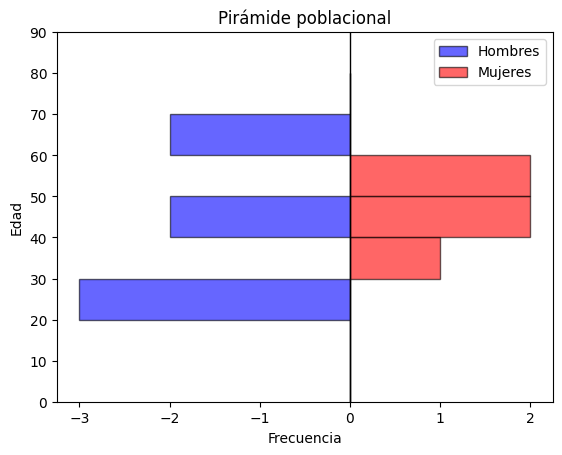

In [ ]:
import matplotlib.pyplot as plt

hombres = df[df[Paciente.COL_SEXO] == "hombre"][Paciente.COL_EDAD]
mujeres = df[df[Paciente.COL_SEXO] == "mujer"][Paciente.COL_EDAD]

bins = list(range(0, 90, 10))

hombres_counts = []
mujeres_counts = []

for i in range(len(bins)-1):
    low, high = bins[i], bins[i+1]
    hombres_counts.append(sum((low <= e < high) for e in hombres))
    mujeres_counts.append(sum((low <= e < high) for e in mujeres))

y = [low + (bins[1]-bins[0])/2 for low in bins[:-1]]

plt.barh(y, [-c for c in hombres_counts], height=10, color="blue", alpha=0.6, label="Hombres", edgecolor="black")

plt.barh(y, mujeres_counts, height=10, color="red", alpha=0.6, label="Mujeres", edgecolor="black")

plt.axvline(0, color="black", linewidth=1)
plt.yticks(range(0, 91, 10))
plt.ylim(0, 90)

plt.xlabel("Frecuencia")
plt.ylabel("Edad")
plt.title("Pirámide poblacional")
plt.legend()
plt.show()

# seaborn

<Axes: >

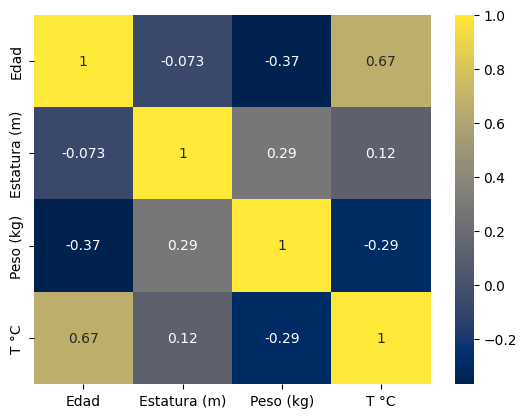

In [ ]:
import seaborn
# cmap Reds Blues Greens coolwarm viridis plasma magma cividis
seaborn.heatmap(df.select_dtypes("number").corr(),annot=True, cmap="cividis")

# plotly

In [ ]:
import plotly.express as px

